# Final Project: Tech Use and Stress Wellness
# Author: Nitish Verma

In [432]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Data Set Description

In [433]:
df = pd.read_csv("Tech_Use_Stress_Wellness.csv", index_col=0)
pd.set_option('display.max_columns',50)
df.head()

,age,gender,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,entertainment_hours,gaming_hours,sleep_duration_hours,sleep_quality,mood_rating,stress_level,physical_activity_hours_per_week,location_type,mental_health_score,uses_wellness_apps,eats_healthy,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day
user_id,,,,,,,,,,,,,,,,,,,,,,,,
1,53,Male,6.8,2.9,2.1,0.5,2.0,2.3,3.0,2.3,2.2,7.1,4.0,5.6,3,4.4,Rural,79.0,True,True,150.4,7.0,3.0,14.0
2,66,Female,4.1,2.1,1.6,0.4,0.8,2.8,3.5,2.0,1.6,6.8,4.0,6.0,4,4.1,Rural,71.0,True,True,124.1,7.0,10.0,15.5
3,43,Male,4.7,3.6,0.0,0.5,1.4,3.7,3.6,1.0,0.9,6.0,4.0,4.3,6,1.4,Urban,67.0,True,True,218.3,11.0,7.0,19.5
4,29,Female,6.0,4.5,0.0,0.2,1.3,4.5,4.0,0.8,0.3,7.3,4.0,1.3,10,0.0,Rural,55.0,True,True,133.7,17.0,14.0,13.9
5,57,Male,6.7,3.4,2.0,0.8,1.2,3.8,3.5,1.2,2.0,7.0,4.0,3.6,6,2.8,Urban,62.0,False,False,192.8,5.0,8.0,26.7


In the **Tech Use & Stress Wellness** Kaggle dataset above, we analyze how data from 5,000 global participants offers a connection between technology use and overall wellness. 

<p> Below, we classify every column of the dataset:
<ul>
<li><b>age</b>: age of person
<li><b>gender</b>: gender of person
<li><b>daily_screen_time_hours</b>: daily screen time (hours)
<li><b>phone_usage_hours</b>: phone screen time (hours)
<li><b>laptop_usage_hours</b>: laptop screen time (hours)  
<li><b>tablet_usage_hours</b>: tablet screen time (hours)
<li><b>tv_usage_hours</b>: tv screen time (hours)
<li><b>social_media_hours</b>: social media screen time (hours)
<li><b>work_related_hours</b>: time spent on work (hours)
<li><b>entertainment_hours</b>: time spent on entertainment (hours)
<li><b>gaming_hours</b>: time spent on gaming (hours)
<li><b>sleep_duration_hours</b>: hours of sleep
<li><b>sleep_quality</b>: quality of sleep
<li><b>mood_rating</b>: mood rating
<li><b>stress_level</b>: level of stress
<li><b>physical_activity_hours_per_week</b>: hours of weekly physical activity
<li><b>location_type</b>: rural, urban, or suburban locations
<li><b>mental_health_score</b>: mental health score (0-100)
<li><b>uses_wellness_apps</b>: does the person use wellness apps
<li><b>eats_healthy</b>: does the person eat healthy
<li><b>caffeine_intake_mg_per_day</b>: caffeine consumption
<li><b>weekly_anxiety_score</b>: weekly anxiety score (0-21)
<li><b>weekly_depression_score</b>: weekly depression score (0-21)
<li><b>mindfulness_minutes_per_day</b>: daily mindfulness minutes
</ul></p>

## Data Preparation and Explanation

First, let's rename some necessary columns and drop any unecessary ones.

In [434]:
df.drop(['work_related_hours', 'entertainment_hours', 'gaming_hours', 'mood_rating', 'location_type', 'mindfulness_minutes_per_day'
        ], axis=1, inplace=True)

In [435]:
df.rename(columns={'daily_screen_time_hours': 'daily_screen_time', 'phone_usage_hours': 'phone', 
                   'laptop_usage_hours': 'laptop'}, inplace=True)
df.rename(columns={'tablet_usage_hours': 'tablet', 'tv_usage_hours': 'tv', 'social_media_hours': 'social_media'
                   }, inplace=True)
df.rename(columns={'sleep_duration_hours': 'sleep_duration', 'physical_activity_hours_per_week': 'physical_activity', 
                   'caffeine_intake_mg_per_day': 'daily_caffeine'}, inplace=True)
df

,age,gender,daily_screen_time,phone,laptop,tablet,tv,social_media,sleep_duration,sleep_quality,stress_level,physical_activity,mental_health_score,uses_wellness_apps,eats_healthy,daily_caffeine,weekly_anxiety_score,weekly_depression_score
user_id,,,,,,,,,,,,,,,,,,
1,53,Male,6.8,2.9,2.1,0.5,2.0,2.3,7.1,4.0,3,4.4,79.0,True,True,150.4,7.0,3.0
2,66,Female,4.1,2.1,1.6,0.4,0.8,2.8,6.8,4.0,4,4.1,71.0,True,True,124.1,7.0,10.0
3,43,Male,4.7,3.6,0.0,0.5,1.4,3.7,6.0,4.0,6,1.4,67.0,True,True,218.3,11.0,7.0
4,29,Female,6.0,4.5,0.0,0.2,1.3,4.5,7.3,4.0,10,0.0,55.0,True,True,133.7,17.0,14.0
5,57,Male,6.7,3.4,2.0,0.8,1.2,3.8,7.0,4.0,6,2.8,62.0,False,False,192.8,5.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,17,Female,7.0,2.2,0.9,0.5,2.3,4.5,5.9,4.0,10,0.0,55.0,False,False,233.0,18.0,16.0
4997,42,Female,1.9,1.5,1.5,0.2,0.0,1.7,8.2,4.0,2,5.3,79.0,False,True,159.3,2.0,1.0
4998,20,Female,6.3,1.5,2.6,0.6,0.8,4.5,7.7,4.0,10,0.1,47.0,False,False,83.0,12.0,17.0


In [436]:
df.describe()

,age,daily_screen_time,phone,laptop,tablet,tv,social_media,sleep_duration,sleep_quality,stress_level,physical_activity,mental_health_score,daily_caffeine,weekly_anxiety_score,weekly_depression_score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,44.70120,5.037860,1.994400,1.555160,0.663060,1.433040,3.276920,7.370080,4.009400,5.718400,2.65934,64.766200,142.321260,8.631800,7.520000
std,17.26688,1.835637,0.890671,1.025994,0.525438,0.928931,1.203655,0.543875,0.663777,2.915064,2.28885,13.095779,50.468392,5.092565,4.672383
min,15.00000,1.000000,0.200000,0.000000,0.000000,0.000000,0.300000,5.400000,1.000000,1.000000,0.00000,31.000000,0.000000,0.000000,0.000000
25%,30.00000,3.700000,1.400000,0.700000,0.200000,0.700000,2.400000,7.000000,4.000000,3.000000,0.60000,54.000000,108.475000,5.000000,4.000000
50%,45.00000,5.000000,2.000000,1.500000,0.600000,1.400000,3.600000,7.400000,4.000000,6.000000,2.30000,65.000000,141.650000,8.000000,7.000000
75%,60.00000,6.300000,2.600000,2.300000,1.000000,2.100000,4.500000,7.700000,4.000000,8.000000,4.20000,75.000000,176.400000,12.000000,11.000000
max,74.00000,10.000000,5.000000,5.000000,2.900000,4.000000,4.500000,9.000000,5.000000,10.000000,11.80000,100.000000,341.200000,21.000000,21.000000


In [437]:
df.age.min()

np.int64(15)

In [438]:
df.age.max()

np.int64(74)

The average daily screen time for all 5,000 participants in our dataset is approximately 5.04 hours.

For the purposes of this study, let's analyze working-age Internet users, namely participants aged between 16 and 64.

In [439]:
df[df['age'].between(16,64)]['daily_screen_time'].mean()

np.float64(5.088128525876871)

The average daily screen time for working-age Internet users is approximately 5.09 hours. We will use this value for future analysis.

In [440]:
df1 = df[df['age'].between(16,64)]
df1

,age,gender,daily_screen_time,phone,laptop,tablet,tv,social_media,sleep_duration,sleep_quality,stress_level,physical_activity,mental_health_score,uses_wellness_apps,eats_healthy,daily_caffeine,weekly_anxiety_score,weekly_depression_score
user_id,,,,,,,,,,,,,,,,,,
1,53,Male,6.8,2.9,2.1,0.5,2.0,2.3,7.1,4.0,3,4.4,79.0,True,True,150.4,7.0,3.0
3,43,Male,4.7,3.6,0.0,0.5,1.4,3.7,6.0,4.0,6,1.4,67.0,True,True,218.3,11.0,7.0
4,29,Female,6.0,4.5,0.0,0.2,1.3,4.5,7.3,4.0,10,0.0,55.0,True,True,133.7,17.0,14.0
5,57,Male,6.7,3.4,2.0,0.8,1.2,3.8,7.0,4.0,6,2.8,62.0,False,False,192.8,5.0,8.0
6,22,Male,8.6,2.4,3.4,1.4,1.1,4.5,6.0,3.0,9,1.4,51.0,False,False,191.4,14.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,17,Female,7.0,2.2,0.9,0.5,2.3,4.5,5.9,4.0,10,0.0,55.0,False,False,233.0,18.0,16.0
4997,42,Female,1.9,1.5,1.5,0.2,0.0,1.7,8.2,4.0,2,5.3,79.0,False,True,159.3,2.0,1.0
4998,20,Female,6.3,1.5,2.6,0.6,0.8,4.5,7.7,4.0,10,0.1,47.0,False,False,83.0,12.0,17.0


## Quality of Findings

First, let's analyze the impact of digital behavior on anxiety, depression, and stress. Since **daily_screen_time** represents cumulative digital device usage, we will compare this opposite our 3 emotional responses shown below.

**weekly_anxiety_score**: According to the Anxiety and Depression Association of America, a 10-14 score represents moderate anxiety and a 15-21 score represents severe anxiety from a cumulative scale of 0-21.

**weekly_depression_score**: The Depression, Anxiety, and Stress Scale (DASS-21) reports that a score of at least 7 represents moderate to severe depression from a cumulative scale of 0-21.

**stress_level**: This will not be based off a formal scale, so we subjectively classify a stress level of at least 6 to be moderate to severe stress from a cumulative scale of 1-10.



In [441]:
df1[df1['daily_screen_time'] > 5.09]['weekly_anxiety_score'].mean()

np.float64(11.481246955674623)

In [442]:
df1[df1['daily_screen_time'] > 5.09]['weekly_depression_score'].mean()

np.float64(9.987335606429616)

In [443]:
df1[df1['daily_screen_time'] > 5.09]['stress_level'].mean()

np.float64(7.624452021432051)

In all 3 cases, the average metrics of all participants who surpass daily screen time usage of 5.09 hours all correlate to moderate to severe anxiety, depression, and stress. Namely, there is a positive correlation between daily screen time usage and anxiety, depression, and stress levels. 

Let us graphically analyze this correlation with 3 scatterplots below:

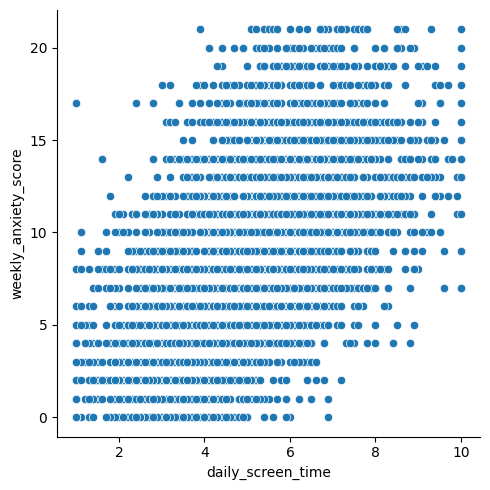

In [444]:
sns.relplot(x='daily_screen_time', y='weekly_anxiety_score', data=df1)

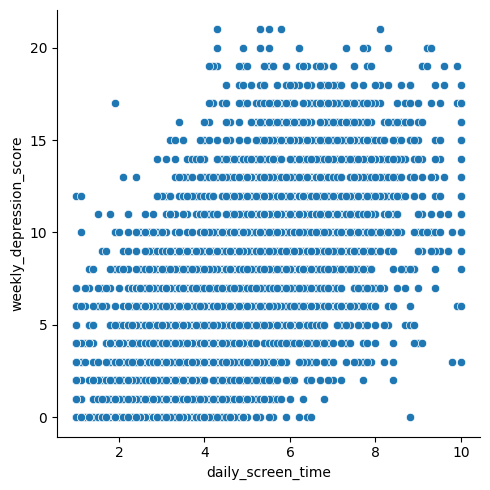

In [445]:
sns.relplot(x='daily_screen_time', y='weekly_depression_score', data=df1)

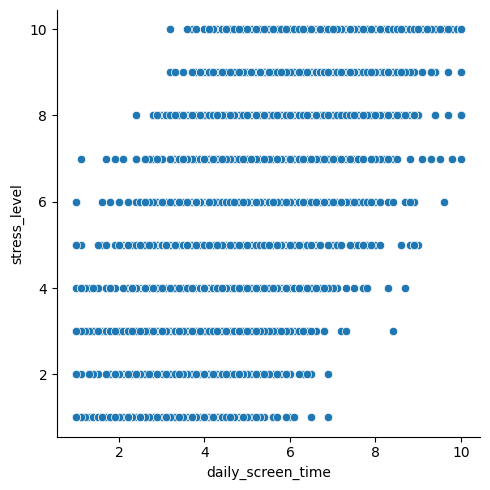

In [446]:
sns.relplot(x='daily_screen_time', y='stress_level', data=df1)

### Finding #1: Daily screen time has a strong positive correlation with weekly anxiety and weekly depression, but only a positive correlation with stress level. Social media companies such as Meta and Reddit should be aware of how their key products impact the mental health of working-age Internet users and how to implement best practices to limit device screen time.

In [488]:
pd.set_option('future.no_silent_downcasting', True)
df = df.replace({True: 1, False: 0})
df

,age,gender,daily_screen_time,phone,laptop,tablet,tv,social_media,sleep_duration,sleep_quality,stress_level,physical_activity,mental_health_score,uses_wellness_apps,eats_healthy,daily_caffeine,weekly_anxiety_score,weekly_depression_score
user_id,,,,,,,,,,,,,,,,,,
1,53,Male,6.8,2.9,2.1,0.5,2.0,2.3,7.1,4.0,3,4.4,79.0,1,1,150.4,7.0,3.0
2,66,Female,4.1,2.1,1.6,0.4,0.8,2.8,6.8,4.0,4,4.1,71.0,1,1,124.1,7.0,10.0
3,43,Male,4.7,3.6,0.0,0.5,1.4,3.7,6.0,4.0,6,1.4,67.0,1,1,218.3,11.0,7.0
4,29,Female,6.0,4.5,0.0,0.2,1.3,4.5,7.3,4.0,10,0.0,55.0,1,1,133.7,17.0,14.0
5,57,Male,6.7,3.4,2.0,0.8,1.2,3.8,7.0,4.0,6,2.8,62.0,0,0,192.8,5.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,17,Female,7.0,2.2,0.9,0.5,2.3,4.5,5.9,4.0,10,0.0,55.0,0,0,233.0,18.0,16.0
4997,42,Female,1.9,1.5,1.5,0.2,0.0,1.7,8.2,4.0,2,5.3,79.0,0,1,159.3,2.0,1.0
4998,20,Female,6.3,1.5,2.6,0.6,0.8,4.5,7.7,4.0,10,0.1,47.0,0,0,83.0,12.0,17.0


In [448]:
from sklearn.linear_model import LinearRegression

In [449]:
model = LinearRegression()

In [450]:
X = df.iloc[:, [10, 16, 17]]
X.head()

,stress_level,weekly_anxiety_score,weekly_depression_score
user_id,,,
1,3,7.0,3.0
2,4,7.0,10.0
3,6,11.0,7.0
4,10,17.0,14.0
5,6,5.0,8.0


In [451]:
y = df.iloc[:, 2]
y.head()

user_id
1    6.8
2    4.1
3    4.7
4    6.0
5    6.7
Name: daily_screen_time, dtype: float64

In [452]:
from sklearn.model_selection import train_test_split
# reserve 30% dataset as testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)   

In [453]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [454]:
model.coef_

array([ 0.4276408 ,  0.00256394, -0.00901747])

In [455]:
model.intercept_

np.float64(2.644867796973826)

In [456]:
model.predict(X_test)

array([6.3787972 , 5.55189364, 6.03355191, ..., 3.47566094, 6.04911024,
       5.57894604], shape=(1500,))

In [457]:
y_pred = model.predict(X_test)
y_pred

array([6.3787972 , 5.55189364, 6.03355191, ..., 3.47566094, 6.04911024,
       5.57894604], shape=(1500,))

In [458]:
from sklearn import metrics

# compute the root of mean squared error of our predictions
print("root of mean squared error: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

# compute the mean absolute error error of our predictions
print("mean absolute error: ", metrics.mean_squared_error(y_test, y_pred))

root of mean squared error:  1.3576054603071523
mean absolute error:  1.8430925858557952


In [459]:
df.daily_screen_time.mean()

np.float64(5.03786)

### Machine Learning for Finding #1: Since the RMSE (1.36) is much smaller than the mean (5.04) and range (10) of the target variable, the linear regression model strongly performs for comparing daily screen time opposite stress level, weekly anxiety score, and weekly depression score.

Next, we analyze the impact of digital behavior on sleep duration and sleep quality. Since daily screen time has a negative impact on stress, anxiety, and depression --> psychologically, one would expect it to have a similar adverse impact on both sleep duration and sleep quality. We will verify whether this assumption holds below.

Once again, **daily_screen_time** will represent our independent variable, while **sleep_duration** and **sleep_quality** will represent dependent variables.

**sleep_duration**: The average working-age Internet user needs at least 7 hours of sleep per night for optimal health.

**sleep_quality**: On a scale of 1-5: 1 represents very poor sleep, 2 represents poor sleep, 3 represents average sleep, 4 represents good sleep, and 5 represents excellent sleep.

In [460]:
df1[df1['daily_screen_time'] > 5.09]['sleep_duration'].mean()

np.float64(7.1909887968826105)

In [461]:
df1[df1['daily_screen_time'] > 5.09]['sleep_quality'].mean()

np.float64(3.688261081344374)

Working-age Internet users who surpassed their cohort's average daily screen time ended up sleeping for at least 7 hours a day and having above-average sleep quality. However, an average does not delineate true correlation between two variables.

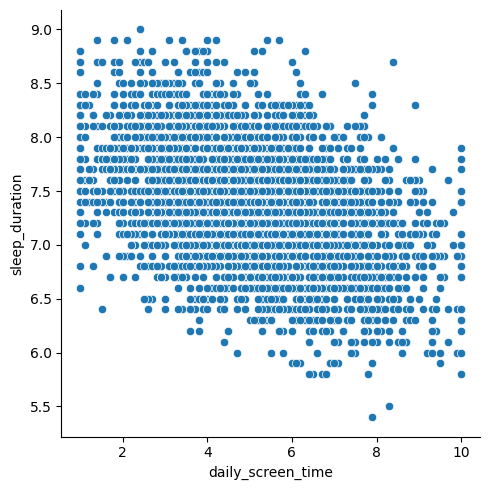

In [462]:
sns.relplot(x='daily_screen_time', y='sleep_duration', data=df1)

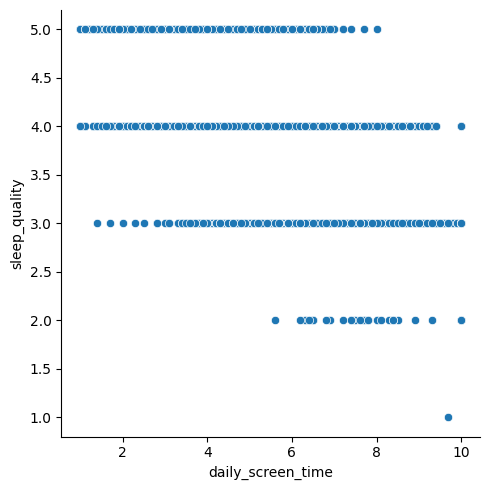

In [463]:
sns.relplot(x='daily_screen_time', y='sleep_quality', data=df1)

As expected, daily screen time has a strongly negative correlation with sleep duration and a negative correlation with sleep quality. As screen time increases, both sleep duration and sleep quality decrease. One common reason for this is bright screens from cell phones at night suppress melatonin, a sleep-inducing hormone.

### Finding #2: Daily screen time has a strongly negative correlation with sleep duration and a negative correlation with sleep quality. Industries with high sleep deprivation rates such as healthcare need to admininister sleep education programs for all of their employees who are reliant on technological devices.

In [464]:
X = df.iloc[:, [8,9]]
X.head()

,sleep_duration,sleep_quality
user_id,,
1,7.1,4.0
2,6.8,4.0
3,6.0,4.0
4,7.3,4.0
5,7.0,4.0


In [465]:
y = df.iloc[:, 2]
y.head()

user_id
1    6.8
2    4.1
3    4.7
4    6.0
5    6.7
Name: daily_screen_time, dtype: float64

In [466]:
from sklearn.model_selection import train_test_split
# reserve 30% dataset as testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)  

In [467]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [468]:
model.coef_

array([-1.04191679, -1.33551083])

In [469]:
model.intercept_

np.float64(18.05668729167195)

In [470]:
model.predict(X_test)

array([4.69188469, 5.52541812, 5.31703476, ..., 4.90026805, 4.17092629,
       5.31703476], shape=(1500,))

In [471]:
y_pred = model.predict(X_test)
y_pred

array([4.69188469, 5.52541812, 5.31703476, ..., 4.90026805, 4.17092629,
       5.31703476], shape=(1500,))

In [472]:
from sklearn import metrics

# compute the root of mean squared error of our predictions
print("root of mean squared error: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

# compute the mean absolute error error of our predictions
print("mean absolute error: ", metrics.mean_squared_error(y_test, y_pred))

root of mean squared error:  1.4536975636168474
mean absolute error:  2.1132366064655583


### Machine Learning for Finding #2: Since the RMSE (1.45) is much smaller than the mean (5.04) and range (10) of the target variable, the linear regression model strongly performs for comparing daily screen time opposite sleep quality and sleep duration.

We now analyze whether wellness apps and high nutrition can offset digital behavior. 

Since we already explored cumulative device usage through daily screen time, we will now explore a new variable: **social media**, to delineate social media usage. We will compare this variable opposite two new categorical variables: **uses_wellness_apps** and **eats_healthy**, namely does the participant use wellness apps and does the participant eat healthy?

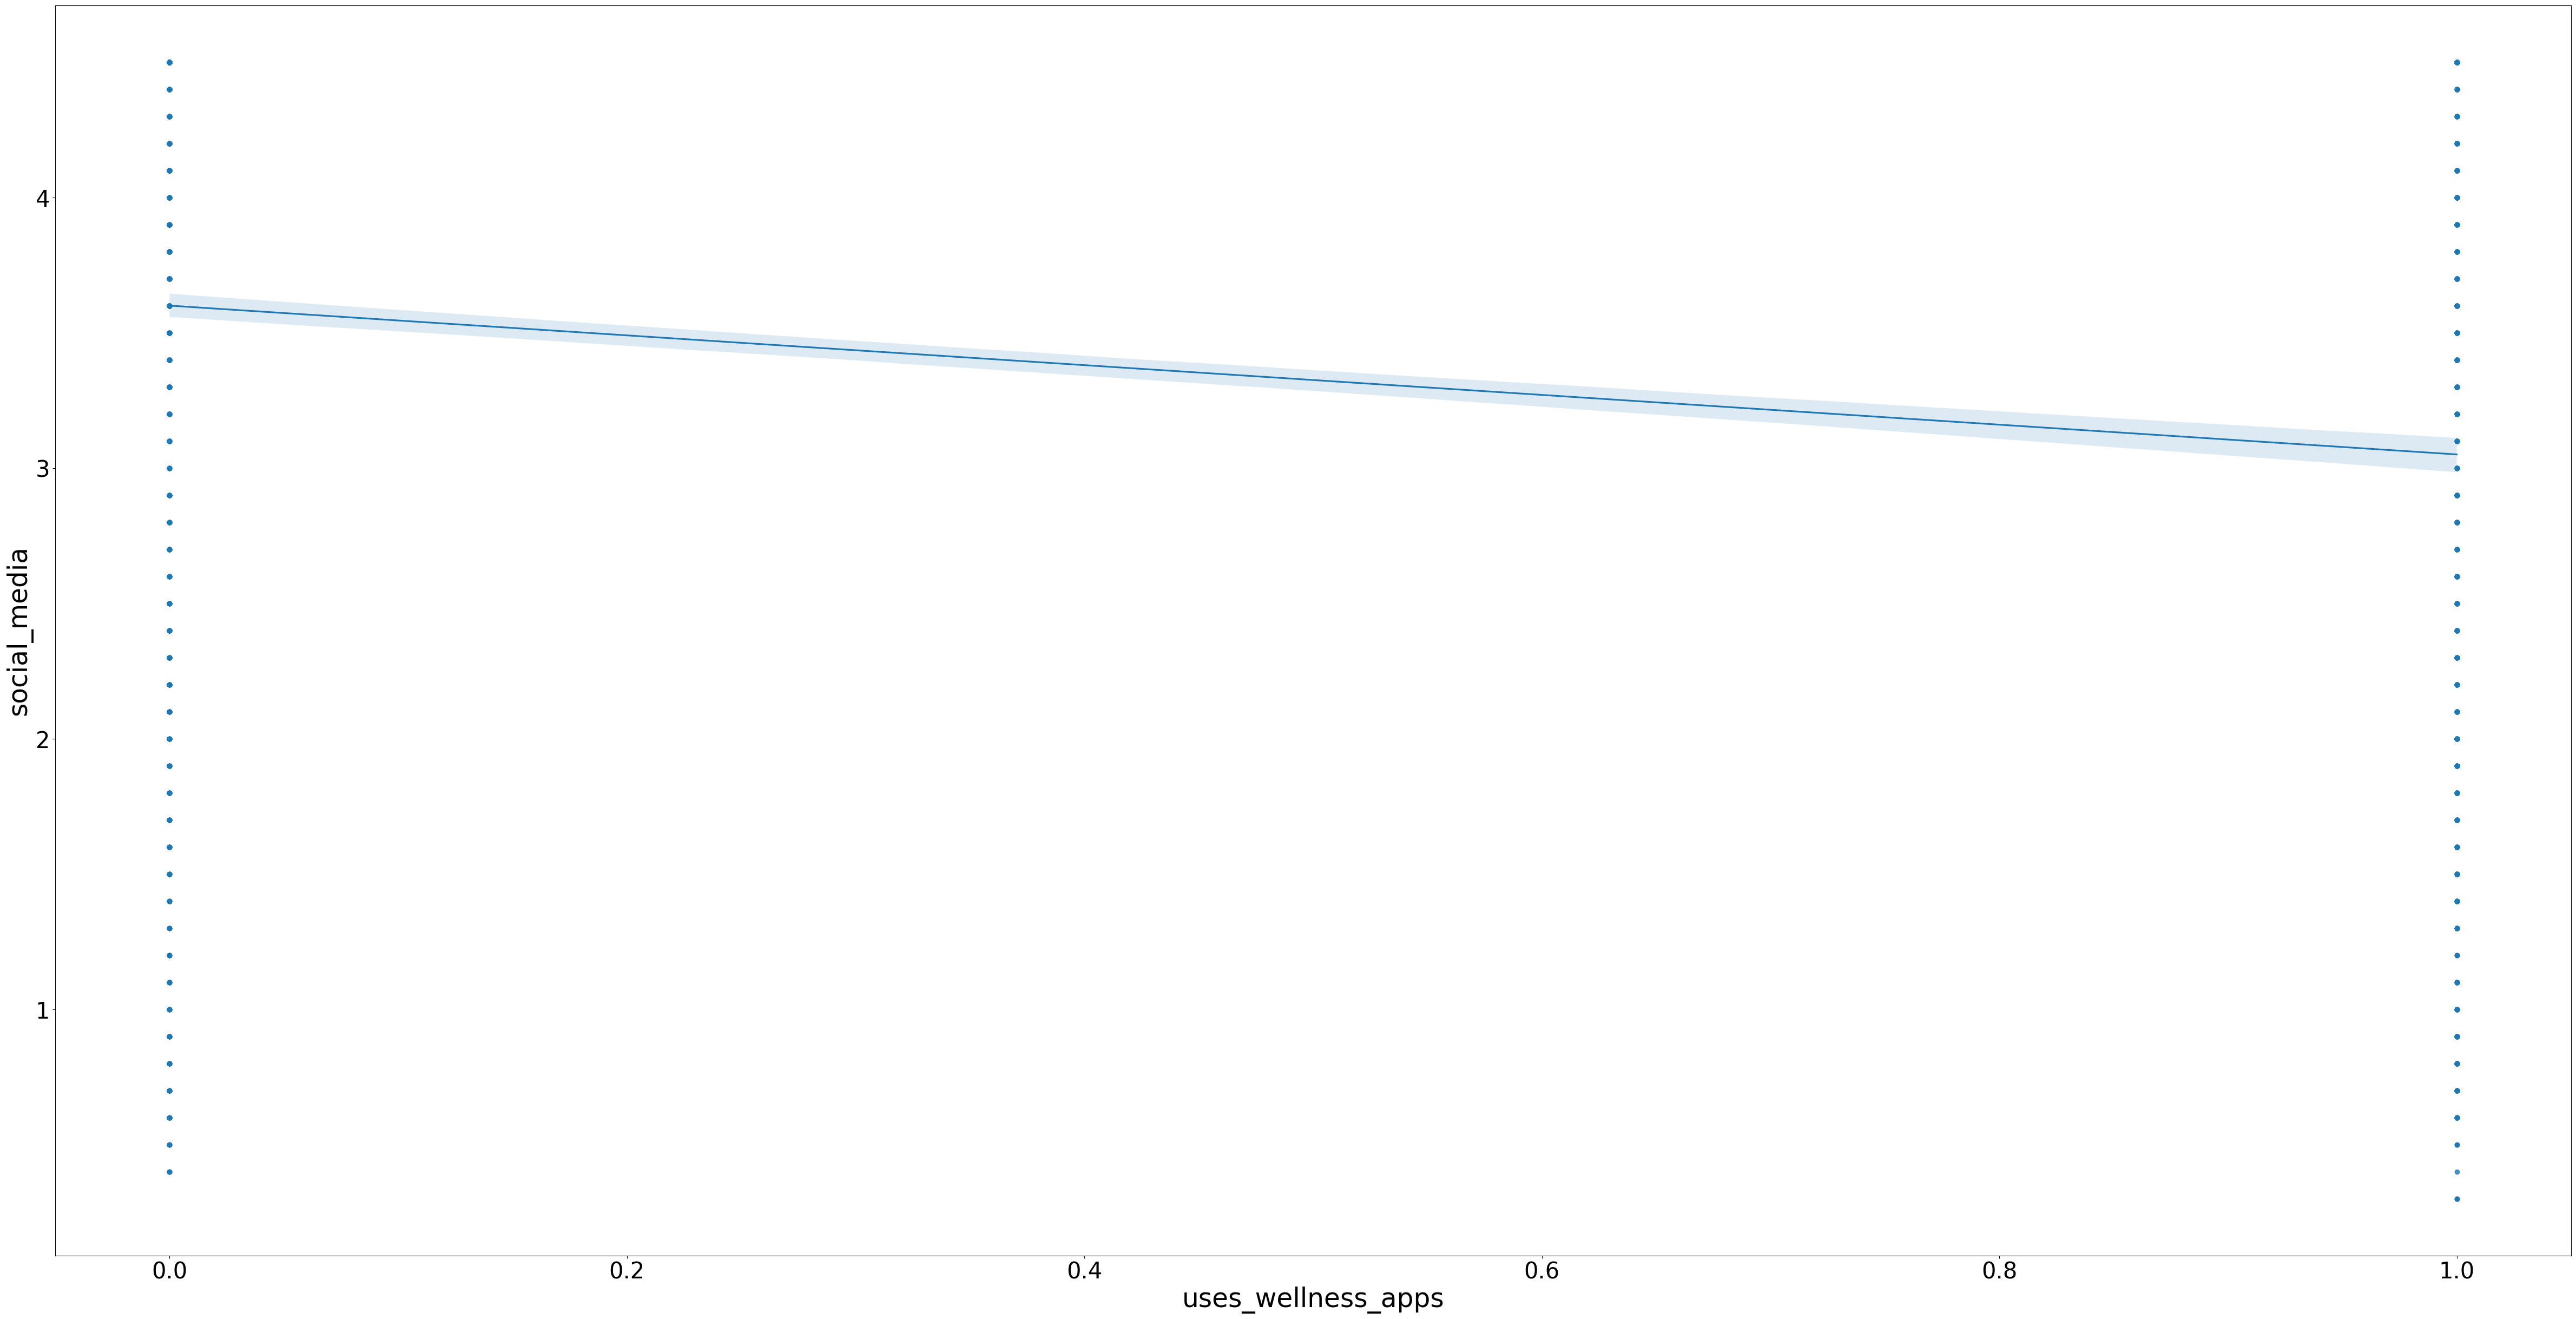

In [473]:
fig3 = sns.regplot(data=df1, x='uses_wellness_apps', y='social_media')
fig3.set_xlabel('uses_wellness_apps', fontsize=35)
fig3.set_ylabel('social_media', fontsize=35)
fig3.tick_params(axis='x', labelsize=30)
fig3.tick_params(axis='y', labelsize=30)
plt.show()

There is a negative correlation between social media and wellness apps.

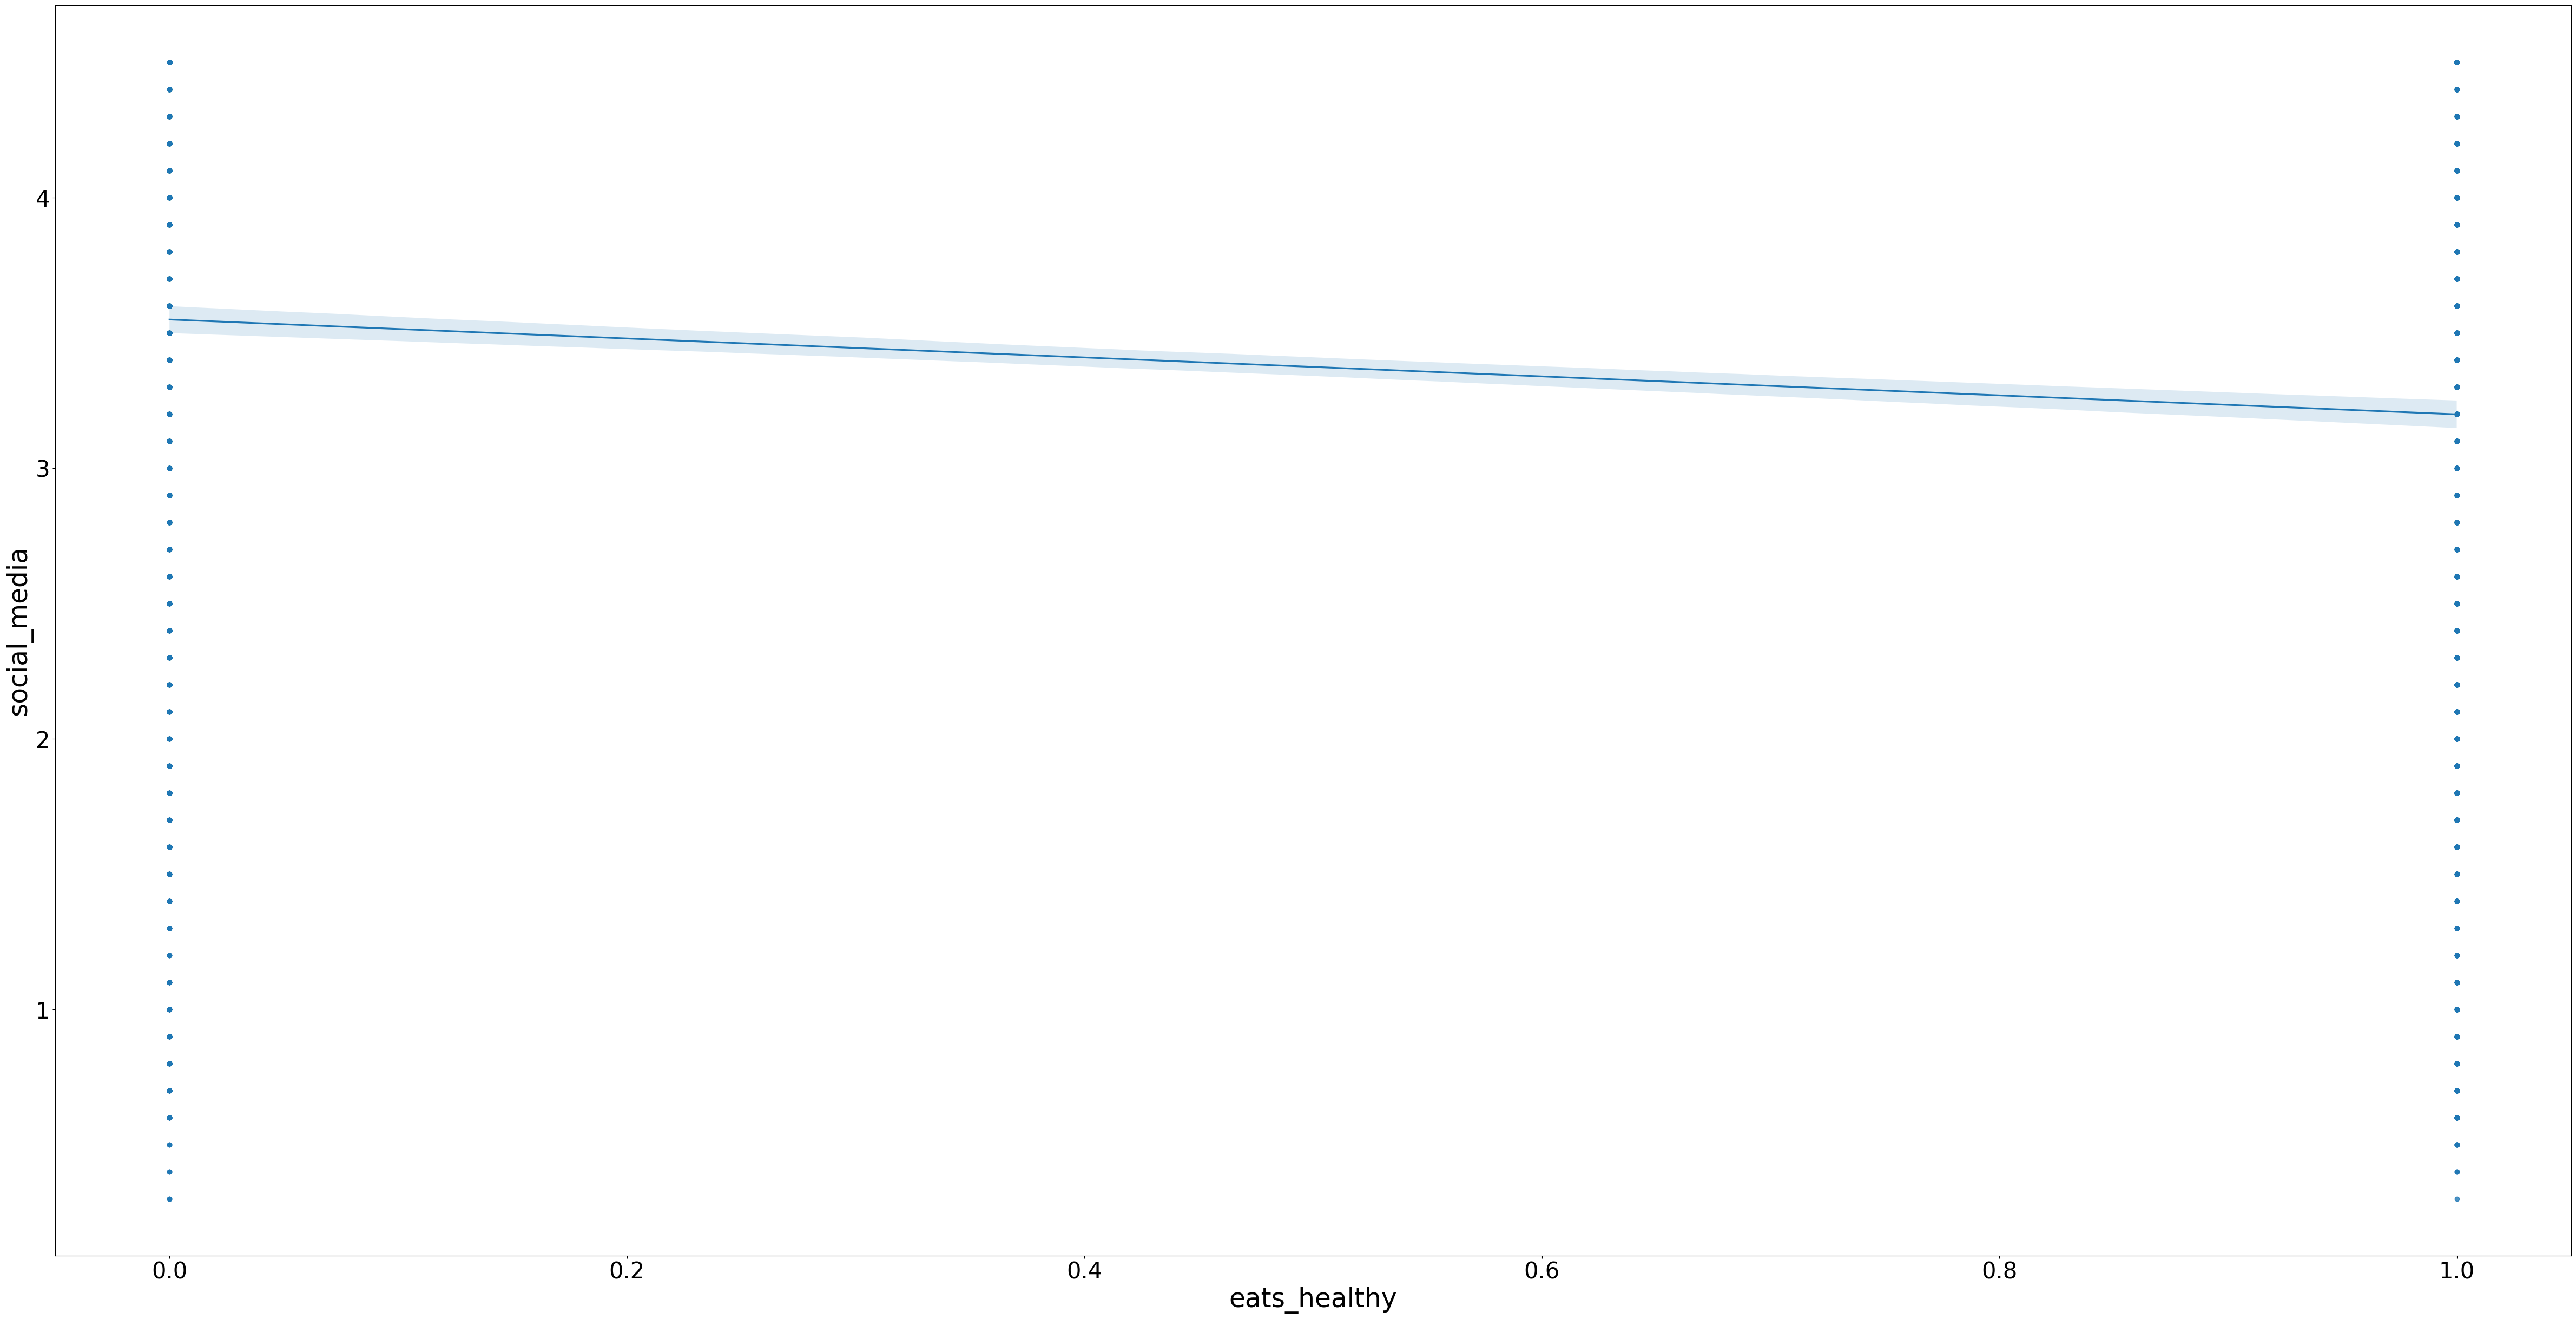

In [474]:
fig7 = sns.regplot(data=df1, x='eats_healthy', y='social_media')
fig7.set_xlabel('eats_healthy', fontsize=35)
fig7.set_ylabel('social_media', fontsize=35)
fig7.tick_params(axis='x', labelsize=30)
fig7.tick_params(axis='y', labelsize=30)
plt.show()

There is a negative correlation between social media and healthy eating.

### Finding #3: Social media negatively correlates with healthy eating and wellness. Therefore, companies should use social media to share tips for better nutrition and promote wellness apps such as Calm and FitBit.

In [475]:
from sklearn.linear_model import LogisticRegression

In [476]:
model = LogisticRegression(solver='liblinear')

In [477]:
X = df.iloc[:,[2,7]]
X.head()

,daily_screen_time,social_media
user_id,,
1,6.8,2.3
2,4.1,2.8
3,4.7,3.7
4,6.0,4.5
5,6.7,3.8


In [478]:
y = df.eats_healthy
y.head()

user_id
1    1
2    1
3    1
4    1
5    0
Name: eats_healthy, dtype: int64

In [479]:
from sklearn.model_selection import train_test_split
# reserve 30% dataset as testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)  

In [480]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [481]:
y_test_pred = model.predict(X_test)

In [482]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.56      0.65      0.60       742
           1       0.59      0.50      0.54       758

    accuracy                           0.57      1500
   macro avg       0.57      0.57      0.57      1500
weighted avg       0.57      0.57      0.57      1500



In [483]:
y = df.uses_wellness_apps
y.head()

user_id
1    1
2    1
3    1
4    1
5    0
Name: uses_wellness_apps, dtype: int64

In [484]:
from sklearn.model_selection import train_test_split
# reserve 30% dataset as testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)  

In [485]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [486]:
y_test_pred = model.predict(X_test)

In [487]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.66      0.83      0.73       915
           1       0.55      0.33      0.41       585

    accuracy                           0.63      1500
   macro avg       0.60      0.58      0.57      1500
weighted avg       0.62      0.63      0.61      1500



### Machine Learning for Finding #3: Low accuracy scores of 0.63 and 0.57 reflect a weak logistic regression model for comparing social media opposite healthy eating and wellness apps, respectively. This was expected since nearly 86% of the 125K entries in the entire dataset are continuous responses, even though logistic regression is a classification algorithm.